# Workflow 4: Parallel | Cricket Stats
Author: Nihit Kumar

---
Parallel workflows are used to execute multiple nodes parallely togther. It is very useful where the nodes are independent of each other

---

**TASK**: Calculate stats for a batsman given the following data  

**States:**  
- `runs`: user input
- `balls`: user input
- `sixes`: user input
- `fours`: user input
- `strike_rate`: Calculation
- `bpb` (Balls per boundary): Calculation
- `bp` (Boundary Percentage): Calculation
- `summary` (Summary of stats): Diplay (Non-AI)

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

In [3]:
class BatsmanAnalysis(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    strike_rate: float
    bp: float # Boundary Percentage
    bpb: float # Balls per boundary
    summary: str

Here we are returning only the values which is supposed to be updated in the state.  
**Reason**: If we return the state simultanously in parallel workflows, it will create a conflict when merging the paralle chains.  

In [27]:
def get_strike_rate(state: BatsmanAnalysis):
    sr = (state['runs'] / state['balls']) * 100
    return {'strike_rate': sr}

In [18]:
def get_boundary_percentage(state: BatsmanAnalysis):
    bp = ((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs']
    return {'bp': bp}

In [19]:
def get_balls_per_boundary(state: BatsmanAnalysis):
    bpb = state['balls'] / (state['fours'] + state['sixes'])
    return {'bpb': bpb}

In [20]:
def get_summary(state:BatsmanAnalysis) -> BatsmanAnalysis:
    summary = f"""
    Strike Rate: {state['strike_rate']} \n
    Balls per boundary: {state['bpb']} \n
    Boundary Percentage: {state['bp']} \n
    Create a summary of the batsman given the stats above
    """
    state['summary'] = summary
    return state

In [21]:
graph = StateGraph(BatsmanAnalysis)

graph.add_node('get_strike_rate', get_strike_rate)
graph.add_node('get_boundary_percentage', get_boundary_percentage)
graph.add_node('get_balls_per_boundary', get_balls_per_boundary)
graph.add_node('get_summary', get_summary)

# Defining Edges
graph.add_edge(START, 'get_strike_rate')
graph.add_edge(START, 'get_boundary_percentage')
graph.add_edge(START, 'get_balls_per_boundary')

graph.add_edge('get_strike_rate', 'get_summary')
graph.add_edge('get_balls_per_boundary', 'get_summary')
graph.add_edge('get_boundary_percentage', 'get_summary')

graph.add_edge('get_summary', END)

workflow = graph.compile()


In [24]:
# Initial State

initial_state = {
    'runs': 400,
    'balls': 120,
    'fours': 25,
    'sixes': 20,
}

In [25]:
final_state = workflow.invoke(initial_state)

In [29]:
print(final_state['summary'])


    Strike Rate: 0.03333333333333333 

    Balls per boundary: 2.6666666666666665 

    Boundary Percentage: 0.55 

    Create a summary of the batsman given the stats above
    


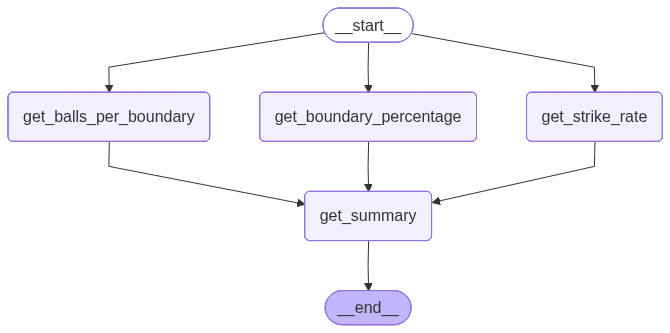

In [30]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())